# Контрольная работа: Введение в анализ данных
**Вариант 1.**  Набор данных: `salary.csv`

**Выполнил:** Бушуев Никита

## 1. Загрузка данных

Загружаем датасет с помощью библиотеки `pandas`. Файл содержит данные о зарплатах специалистов в области Data Science за 2020-2022 годы. Разделитель - точка с запятой (`;`).

In [85]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('salary.csv', sep=';')
print(f'Датасет загружен. Размер: {df.shape[0]} строк, {df.shape[1]} столбцов')

Датасет загружен. Размер: 401 строк, 8 столбцов


## 2. Первые 20 строк (метод head)

Выводим первые 20 строк для предварительного ознакомления с данными.

In [86]:
df.head(20)

,work_year,employment_type,job_title,salary,salary_in_usd,employee_residence,company_location,company_size
0,2020.0,FT,Data SCIENTIST,70000.0,79833.0,DE,DE,L
1,2020.0,FT,Product Data Analyst,20000.0,20000.0,HN,HN,S
2,2020.0,FT,Data Analyst,72000.0,72000.0,US,US,L
3,2020.0,FT,Data Scientist,11000000.0,35735.0,HU,HU,L
4,2020.0,FT,Data Scientist,45000.0,51321.0,FR,FR,S
5,2020.0,FT,Data Scientist,3000000.0,40481.0,IN,IN,L
6,2020.0,FT,Data Scientist,35000.0,39916.0,FR,FR,M
7,2020.0,FT,Data Analyst,85000.0,85000.0,US,US,L
8,2020.0,FT,Data Analyst,8000.0,8000.0,PK,PK,Large
9,2020.0,FT,Data Engineer,4450000.0,41689.0,JP,JP,S


## 3. Обзор данных - описание столбцов и предметной области

**Предметная область:** данные о зарплатах IT-специалистов в сфере Data Science за 2020-2022 годы из различных стран мира.

**Описание столбцов:**

| Столбец | Описание |
|---|---|
| `work_year` | Год выплаты заработной платы |
| `employment_type` | Тип занятости: FT (Full-time), PT (Part-time), FL (Freelance) |
| `job_title` | Должность специалиста |
| `salary` | Зарплата за год в местной валюте |
| `salary_in_usd` | Зарплата в долларах США |
| `employee_residence` | Страна проживания сотрудника (код ISO) |
| `company_location` | Страна главного офиса компании (код ISO) |
| `company_size` | Размер компании: S (малая, <50), M (средняя, 50-250), L (крупная, >250) |

## 4. Метод info() - общая информация о данных

Оцениваем типы данных, количество строк и наличие пропусков.

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 401 entries, 0 to 400
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   work_year           401 non-null    float64
 1   employment_type     401 non-null    object 
 2   job_title           401 non-null    object 
 3   salary              398 non-null    float64
 4   salary_in_usd       401 non-null    float64
 5   employee_residence  401 non-null    object 
 6   company_location    401 non-null    object 
 7   company_size        401 non-null    object 
dtypes: float64(3), object(5)
memory usage: 25.2+ KB


**Наблюдения:**
- Всего **401 запись**, 8 столбцов
- Столбец `salary` имеет **3 пропуска** (Non-Null Count: 398 вместо 401)
- `work_year` определён как `float64` - хотя год является целым числом, требует исправления

## 5. Метод describe() - статистика числовых столбцов

In [109]:
df.describe().apply(lambda x: x.map('{:,.2f}'.format))

,work_year,salary,salary_in_usd
count,345.00,345.00,345.00
mean,"2,021.46","313,691.04","101,787.71"
std,0.70,"1,800,267.58","59,038.36"
min,"2,020.00","4,000.00","2,859.00"
25%,"2,021.00","63,900.00","60,000.00"
50%,"2,022.00","105,000.00","99,000.00"
75%,"2,022.00","150,000.00","135,000.00"
max,"2,022.00","30,400,000.00","412,000.00"


**Анализ числовых столбцов:**

- `work_year`: данные охватывают период 2020–2022 гг. Среднее = 2021.46, медиана - 2022.
- `salary`: диапазон от 4 000 до 30 400 000. Среднее (= 313 691) значительно превышает медиану (= 105 000) - признак правостороннего распределения из-за выбросов (зарплаты в нелатинских валютах). Максимальное значение 30 400 000 - очевидный выброс.
- `salary_in_usd`: диапазон 2 859-412 000 USD. Медиана около 100 000 USD - типичная зарплата Data Scientist в США.

## 6. Названия столбцов - проверка и анализ

Выводим названия столбцов и проверяем на наличие проблем.

In [89]:
print('Названия столбцов:')
print(df.columns.tolist())
print()
# Проверяем на пробелы, смешанный регистр
for col in df.columns:
    issues = []
    if col != col.lower():
        issues.append('содержит заглавные буквы')
    if ' ' in col:
        issues.append('содержит пробел')
    if issues:
        print(f'Проблема в столбце "{col}": {", ".join(issues)}')
    else:
        print(f'Столбец "{col}": OK')

Названия столбцов:
['work_year', 'employment_type', 'job_title', 'salary', 'salary_in_usd', 'employee_residence', 'company_location', 'company_size']

Столбец "work_year": OK
Столбец "employment_type": OK
Столбец "job_title": OK
Столбец "salary": OK
Столбец "salary_in_usd": OK
Столбец "employee_residence": OK
Столбец "company_location": OK
Столбец "company_size": OK


**Вывод:** Все названия столбцов корректны - используется snake_case, пробелов нет, язык единый (английский). Переименование не требуется.

## 7. Проверка и устранение пропусков

In [90]:
print('Количество пропусков по столбцам:')
print(df.isna().sum())
print()
print('Строки с пропусками в столбце salary:')
display(df[df['salary'].isna()])

Количество пропусков по столбцам:
work_year             0
employment_type       0
job_title             0
salary                3
salary_in_usd         0
employee_residence    0
company_location      0
company_size          0
dtype: int64

Строки с пропусками в столбце salary:


,work_year,employment_type,job_title,salary,salary_in_usd,employee_residence,company_location,company_size
369,2022.0,FT,Data Scientist,NaN,210000.0,US,US,M
371,2022.0,FT,Data Scientist,NaN,210000.0,US,US,M
380,2022.0,FT,Data Analyst,NaN,110925.0,US,US,M


**Анализ пропусков:**

- Пропуски обнаружены только в столбце `salary` - **3 строки**.
- Для всех трёх записей заполнен `salary_in_usd` (210 000 и 110 925 USD) и `employee_residence = 'US'`.
- Поскольку для US-сотрудников валюта зарплаты - USD, `salary` равна `salary_in_usd`.

**Решение:** заполнить пропуски значениями из `salary_in_usd`.

In [91]:
# Заполняем пропуски в salary значениями из salary_in_usd
df['salary'] = df['salary'].fillna(df['salary_in_usd'])
print('Пропуски после заполнения:')
print(df.isna().sum())

Пропуски после заполнения:
work_year             0
employment_type       0
job_title             0
salary                0
salary_in_usd         0
employee_residence    0
company_location      0
company_size          0
dtype: int64


## 8. Проверка и устранение дубликатов

### 8.1 Явные дубликаты

In [92]:
print('Количество явных дубликатов:', df.duplicated().sum())
print()
print('Примеры дубликатов:')
display(df[df.duplicated()].head(10))

Количество явных дубликатов: 56

Примеры дубликатов:


,work_year,employment_type,job_title,salary,salary_in_usd,employee_residence,company_location,company_size
104,2021.0,FT,Data Scientist,76760.0,90734.0,DE,DE,L
130,2021.0,FT,Data Engineer,200000.0,200000.0,US,US,L
172,2022.0,FT,Data Engineer,40000.0,52351.0,GB,GB,M
189,2022.0,FT,Data Analyst,90320.0,90320.0,US,US,M
190,2022.0,FT,Data Analyst,112900.0,112900.0,US,US,M
191,2022.0,FT,Data Analyst,90320.0,90320.0,US,US,M
193,2022.0,FT,Data Engineer,132320.0,132320.0,US,US,M
208,2022.0,FT,Data Scientist,123000.0,123000.0,US,US,M
209,2022.0,FT,Data Engineer,60000.0,78526.0,GB,GB,M
215,2022.0,FT,Data Analyst,130000.0,130000.0,CA,CA,M


**Явных дубликатов - 56.** Это полные повторения строк. Возможно, они появились из-за объединения нескольких источников данных или ошибки при выгрузке. Удаляем все дубликаты.

In [93]:
df = df.drop_duplicates().reset_index(drop=True)
print('Количество строк после удаления дубликатов:', len(df))
print('Дубликатов осталось:', df.duplicated().sum())

Количество строк после удаления дубликатов: 345
Дубликатов осталось: 0


### 8.2 Неявные дубликаты

Проверяем категориальные столбцы на наличие альтернативных написаний.

In [94]:
print('Уникальные значения job_title:')
print(sorted(df['job_title'].unique()))
print()
print('Частота по job_title:')
print(df['job_title'].value_counts())

Уникальные значения job_title:
['Data Analyst', 'Data Analytics Engineer', 'Data Analytics Lead', 'Data Analytics Manager', 'Data AnalyticsManager', 'Data Engineer', 'Data SCIENTIST', 'Data Science Engineer', 'Data Scientist', 'DataScientist', 'Head of Data Science', 'Head of Machine Learning', 'Machine Learning Developer', 'Machine Learning Manager', 'NLP Engineer', 'Product Data Analyst']

Частота по job_title:
job_title
Data Scientist                125
Data Engineer                 114
Data Analyst                   77
Data Analytics Manager          6
Head of Data Science            4
Data Analytics Engineer         4
Data Science Engineer           3
Product Data Analyst            2
Machine Learning Developer      2
DataScientist                   2
Machine Learning Manager        1
Data SCIENTIST                  1
Head of Machine Learning        1
NLP Engineer                    1
Data Analytics Lead             1
Data AnalyticsManager           1
Name: count, dtype: int64


**Обнаружены неявные дубликаты в `job_title`:**
- `'Data SCIENTIST'` - неправильный регистр, должно быть `'Data Scientist'`
- `'DataScientist'` (2 строки) - пропущен пробел, должно быть `'Data Scientist'`
- `'Data AnalyticsManager'` - пропущен пробел, должно быть `'Data Analytics Manager'`

In [95]:
# Исправляем неявные дубликаты в job_title
implicit_dups = {
    'Data SCIENTIST': 'Data Scientist',
    'DataScientist': 'Data Scientist',
    'Data AnalyticsManager': 'Data Analytics Manager'
}
df['job_title'] = df['job_title'].replace(implicit_dups)
print('После исправления job_title:')
print(df['job_title'].value_counts())

После исправления job_title:
job_title
Data Scientist                128
Data Engineer                 114
Data Analyst                   77
Data Analytics Manager          7
Data Analytics Engineer         4
Head of Data Science            4
Data Science Engineer           3
Machine Learning Developer      2
Product Data Analyst            2
Machine Learning Manager        1
Head of Machine Learning        1
NLP Engineer                    1
Data Analytics Lead             1
Name: count, dtype: int64


In [96]:
print('Уникальные значения company_size:')
print(df['company_size'].unique())
print()
print('Частота по company_size:')
print(df['company_size'].value_counts())

Уникальные значения company_size:
['L' 'S' 'M' 'Large']

Частота по company_size:
company_size
M        208
L         99
S         37
Large      1
Name: count, dtype: int64


**Обнаружен неявный дубликат в `company_size`:** `'Large'` (1 строка) - нестандартное написание вместо `'L'`. Исправляем.

In [97]:
df['company_size'] = df['company_size'].replace({'Large': 'L'})
print('После исправления company_size:')
print(df['company_size'].value_counts())

После исправления company_size:
company_size
M    208
L    100
S     37
Name: count, dtype: int64


In [98]:
print('Уникальные значения employment_type:')
print(df['employment_type'].value_counts())

Уникальные значения employment_type:
employment_type
FT    338
PT      5
FL      2
Name: count, dtype: int64


**`employment_type`:** значения `FT`, `PT`, `FL` - корректны, неявных дубликатов нет.

## 9. Проверка и исправление типов данных

In [99]:
df.dtypes

,0
work_year,float64
employment_type,object
job_title,object
salary,float64
salary_in_usd,float64
employee_residence,object
company_location,object
company_size,object


**Проблемы с типами данных:**
- `work_year`: `float64` - должен быть `int64` (год не может быть дробным)

Исправляем:

In [100]:
df['work_year'] = df['work_year'].astype(int)

print('Типы данных после исправления:')
print(df.dtypes)

Типы данных после исправления:
work_year               int64
employment_type        object
job_title              object
salary                float64
salary_in_usd         float64
employee_residence     object
company_location       object
company_size           object
dtype: object


In [101]:
print('Итоговый датасет:')
df.info()
print()
print('Первые 5 строк итогового датасета:')
display(df.head())

Итоговый датасет:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345 entries, 0 to 344
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   work_year           345 non-null    int64  
 1   employment_type     345 non-null    object 
 2   job_title           345 non-null    object 
 3   salary              345 non-null    float64
 4   salary_in_usd       345 non-null    float64
 5   employee_residence  345 non-null    object 
 6   company_location    345 non-null    object 
 7   company_size        345 non-null    object 
dtypes: float64(2), int64(1), object(5)
memory usage: 21.7+ KB

Первые 5 строк итогового датасета:


,work_year,employment_type,job_title,salary,salary_in_usd,employee_residence,company_location,company_size
0,2020,FT,Data Scientist,70000.0,79833.0,DE,DE,L
1,2020,FT,Product Data Analyst,20000.0,20000.0,HN,HN,S
2,2020,FT,Data Analyst,72000.0,72000.0,US,US,L
3,2020,FT,Data Scientist,11000000.0,35735.0,HU,HU,L
4,2020,FT,Data Scientist,45000.0,51321.0,FR,FR,S


## 10. Итоговый вывод по работе

В ходе предварительного анализа датасета `salary.csv` были выявлены и устранены следующие проблемы:

| Вид проблемы | Описание | Действие | Результат |
|---|---|---|---|
| Пропуски | 3 пропуска в `salary` | Заполнены значениями из `salary_in_usd` (US-сотрудники) | 0 пропусков |
| Явные дубликаты | 56 полностью повторяющихся строк | Удалены методом `drop_duplicates()` | 401 - 345 строки |
| Неявные дубликаты в `job_title` | `Data SCIENTIST`, `DataScientist` , `Data AnalyticsManager` | Заменены корректными вариантами | 16 - 13 уникальных должностей |
| Неявные дубликаты в `company_size` | `Large` (вместо `L`) | Заменено на `L` | 4 - 3 уникальных значения |
| Тип данных `work_year` | `float64` вместо `int64` | Приведён к `int64` | Корректный тип |

**Итоговый датасет:** 345 строки, 8 столбцов, пропусков нет, типы данных соответствуют действительности.

**Ключевые наблюдения из данных:**
- 98% специалистов работают в формате Full-time (FT)
- Наиболее распространённые должности: Data Scientist (126), Data Engineer (114), Data Analyst (77)
- Медианная зарплата специалистов в USD - ~99 000 USD/год
- Специалисты из крупных компаний зарабатывают меньше, чем из средних (медиана L < M) - возможно, влияет география
- Количество записей растёт год от года: 42 (2020) - 103 (2021) - 198 (2022), что отражает рост рынка Data Science

## Визуализации

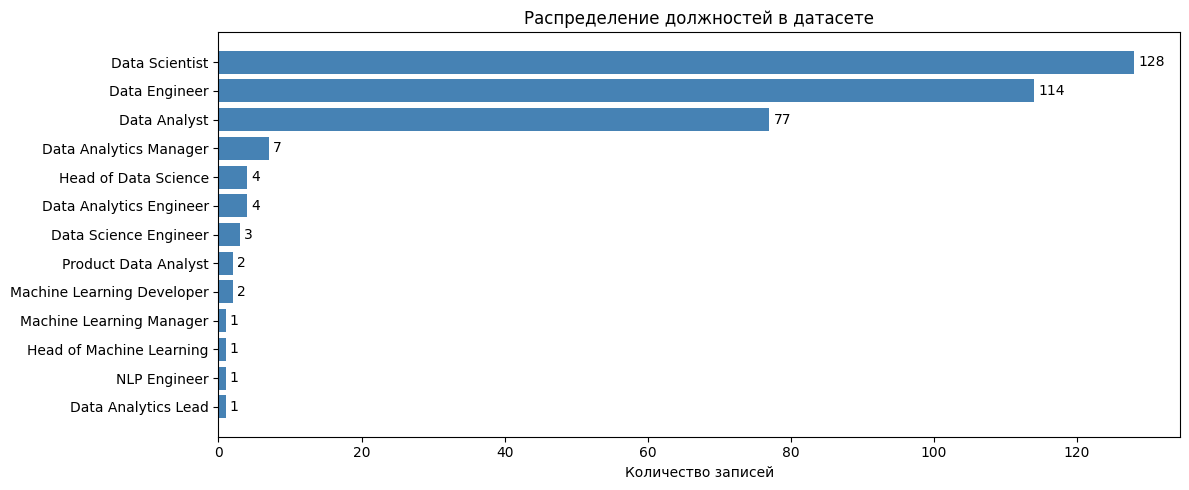

In [102]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (12, 5)

# График 1: Количество записей по должностям
job_counts = df['job_title'].value_counts().sort_values()
fig, ax = plt.subplots()
bars = ax.barh(job_counts.index, job_counts.values, color='steelblue')
ax.bar_label(bars, padding=3)
ax.set_xlabel('Количество записей')
ax.set_title('Распределение должностей в датасете')
plt.tight_layout()
plt.savefig('viz_jobs.png', dpi=100)
plt.show()

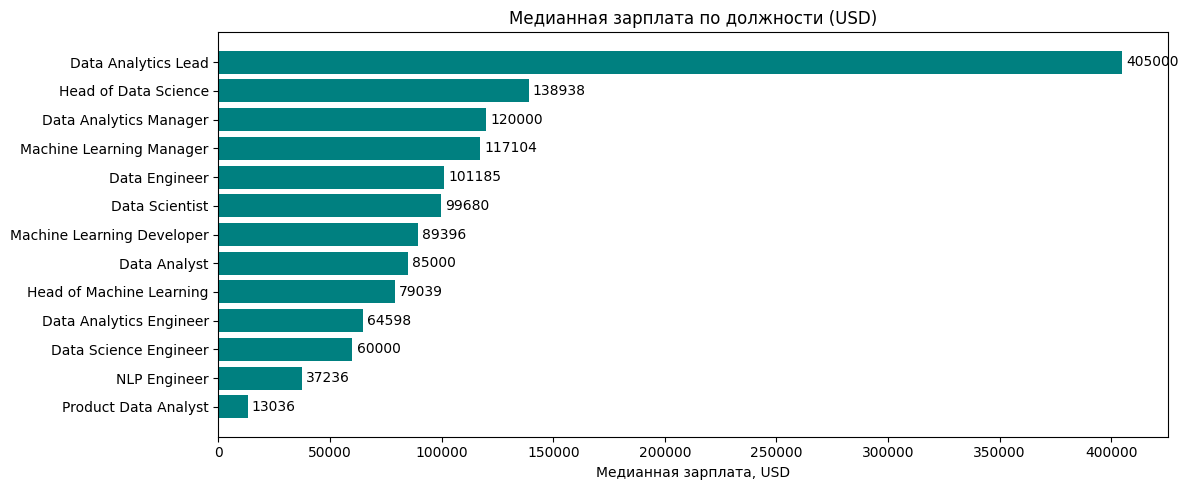

In [103]:
# График 2: Медианная зарплата по должности
med_sal = df.groupby('job_title')['salary_in_usd'].median().sort_values()
fig, ax = plt.subplots()
bars = ax.barh(med_sal.index, med_sal.values, color='teal')
ax.bar_label(bars, fmt='%.0f', padding=3)
ax.set_xlabel('Медианная зарплата, USD')
ax.set_title('Медианная зарплата по должности (USD)')
plt.tight_layout()
plt.savefig('viz_salary.png', dpi=100)
plt.show()

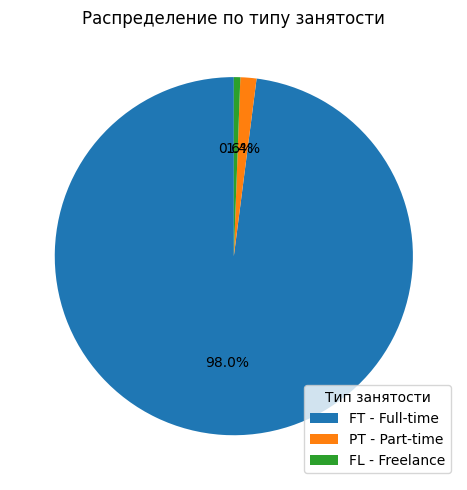

In [108]:
# График 3: Тип занятости
emp_labels = {'FT': 'Full-time', 'PT': 'Part-time', 'FL': 'Freelance'}
emp_counts = df['employment_type'].value_counts()

legend_labels = [f"{k} - {v}" for k, v in emp_labels.items() if k in emp_counts.index]
emp_counts.index = [emp_labels.get(x, x) for x in emp_counts.index]

fig, ax = plt.subplots(figsize=(7, 5))
wedges, texts, autotexts = ax.pie(
    emp_counts,
    labels = None,
    autopct='%1.1f%%',
    startangle=90
)
ax.legend(
    wedges,
    legend_labels,
    title='Тип занятости',
    loc='lower right'
)
ax.set_title('Распределение по типу занятости')
plt.tight_layout()
plt.savefig('viz_employment.png', dpi=100)
plt.show()

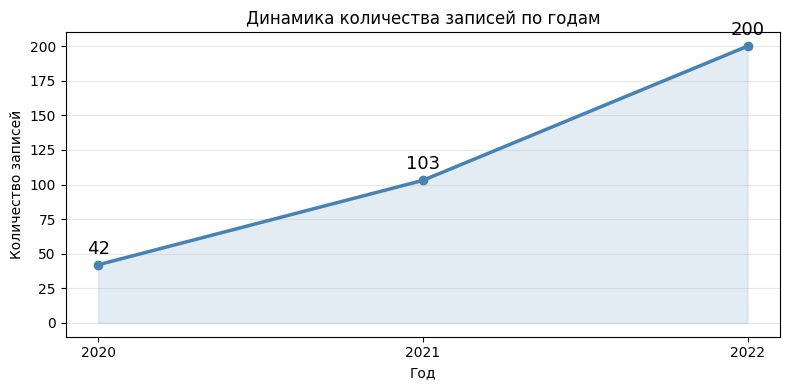

In [105]:
# График 4: Динамика по годам
year_counts = df['work_year'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(year_counts.index.astype(str), year_counts.values, marker='o', linewidth=2.5, color='steelblue')
ax.fill_between(range(len(year_counts)), year_counts.values, alpha=0.15, color='steelblue')
for i, (x, y) in enumerate(zip(year_counts.index.astype(str), year_counts.values)):
    ax.annotate(str(y), (x, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=13)
ax.set_xticks(year_counts.index.astype(str))
ax.set_xlabel('Год')
ax.set_ylabel('Количество записей')
ax.set_title('Динамика количества записей по годам')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('viz_years.png', dpi=100)
plt.show()